In [1]:
import pandas as pd
import time
import os
from openai import OpenAI
from dotenv import load_dotenv
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Setup Data

In [2]:
load_dotenv()
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

file_input = '../Dataset/test_set.csv'
kolom_teks = 'komentar_super_clean'

BATCH_SIZE = 8          
DELAY = 1.5            
CHECKPOINT_FILE = "../Prediction Results/progress_checkpoint.csv"

df = pd.read_csv(file_input)

In [3]:
df_sample = df.copy()

# Checkpoint

In [4]:
if os.path.exists(CHECKPOINT_FILE):
    print("Melanjutkan dari checkpoint...")
    df_sample = pd.read_csv(CHECKPOINT_FILE)
else:
    df_sample['Prediksi_ZeroShot'] = None
    df_sample['Prediksi_FewShot'] = None

Melanjutkan dari checkpoint...


# Evaluasi Metriks

In [5]:
def hitung_metrik(y_true, y_pred, nama):
    print(f"\n--- {nama} ---")
    print(f"Akurasi  : {accuracy_score(y_true, y_pred)*100:.2f}%")
    print(f"Precision: {precision_score(y_true, y_pred)*100:.2f}%")
    print(f"Recall   : {recall_score(y_true, y_pred)*100:.2f}%")
    print(f"F1 Score : {f1_score(y_true, y_pred)*100:.2f}%")

# GPT

In [6]:
def call_gpt(system_prompt, user_prompt):
    for attempt in range(5):
        try:
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                temperature=0.0,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ]
            )
            return response.choices[0].message.content

        except Exception as e:
            print(f"Error: {e}")

            if "rate_limit" in str(e):
                print("Rate limit kena, tunggu 15 detik")
                time.sleep(15)
            else:
                time.sleep(3)

    return None

# Prompt untuk GPT

In [7]:
def build_prompt(batch_texts):
    teks_list = ""
    for i, teks in enumerate(batch_texts, 1):
        teks_list += f"{i}. {teks}\n"

    return f"""
Klasifikasikan komentar berikut:

{teks_list}

Jawab STRICT dengan format:
1. PREDIKSI: YA atau TIDAK
2. PREDIKSI: YA atau TIDAK
dst.
"""

# PARSER

In [8]:
def parse_output(output, batch_size):
    hasil = []

    if output is None:
        return [None]*batch_size

    lines = output.upper().split("\n")

    for line in lines:
        if "PREDIKSI" in line:
            if "YA" in line:
                hasil.append(1)
            elif "TIDAK" in line:
                hasil.append(0)

    while len(hasil) < batch_size:
        hasil.append(None)

    return hasil[:batch_size]

# PROMPT ZERO SHOT & FEW SHOT

In [9]:
system_zero = "Kamu adalah sistem deteksi judi online. Jawab hanya dengan 'PREDIKSI: YA' atau 'PREDIKSI: TIDAK'."

system_few = """
Kamu adalah sistem pakar deteksi judi online.

Contoh:
1. "slot gacor maxwin hari ini" → PREDIKSI: YA
2. "mobilnya bagus banget" → PREDIKSI: TIDAK
3. "main di situs terpercaya bonus besar" → PREDIKSI: YA
4. "lagi makan siang" → PREDIKSI: TIDAK

Ikuti pola ini dan jawab hanya dengan format:
PREDIKSI: YA atau PREDIKSI: TIDAK
"""

In [10]:
def run_experiment(system_prompt, kolom_prediksi):
    for i in range(0, len(df_sample), BATCH_SIZE):

        # skip kalau sudah ada hasil
        if pd.notnull(df_sample.loc[i, kolom_prediksi]):
            continue

        batch = df_sample.iloc[i:i+BATCH_SIZE]
        texts = [str(x)[:512] for x in batch[kolom_teks]]

        prompt = build_prompt(texts)
        output = call_gpt(system_prompt, prompt)

        parsed = parse_output(output, len(texts))

        df_sample.loc[i:i+len(parsed)-1, kolom_prediksi] = parsed

        print(f"Batch {i//BATCH_SIZE + 1} selesai")

        # checkpoint setiap batch
        df_sample.to_csv(CHECKPOINT_FILE, index=False)

        time.sleep(DELAY)

# RUN MODEL

In [11]:
print("RUN ZERO-SHOT")
run_experiment(system_zero, 'Prediksi_ZeroShot')

print("RUN FEW-SHOT")
run_experiment(system_few, 'Prediksi_FewShot')

RUN ZERO-SHOT
RUN FEW-SHOT


# EVALUASI

In [12]:
df_sample['Prediksi_ZeroShot'] = df_sample['Prediksi_ZeroShot'].astype('Int64')
df_sample['Prediksi_FewShot'] = df_sample['Prediksi_FewShot'].astype('Int64')

mask_zero = df_sample['Prediksi_ZeroShot'].notnull()
mask_few = df_sample['Prediksi_FewShot'].notnull()

hitung_metrik(df_sample.loc[mask_zero, 'label'], df_sample.loc[mask_zero, 'Prediksi_ZeroShot'], "ZERO-SHOT")

hitung_metrik(df_sample.loc[mask_few, 'label'], df_sample.loc[mask_few, 'Prediksi_FewShot'], "FEW-SHOT")


--- ZERO-SHOT ---
Akurasi  : 86.95%
Precision: 94.99%
Recall   : 72.09%
F1 Score : 81.97%

--- FEW-SHOT ---
Akurasi  : 90.91%
Precision: 95.43%
Recall   : 81.83%
F1 Score : 88.11%


In [13]:
df_final = df_sample[[kolom_teks, 'label', 'Prediksi_ZeroShot', 'Prediksi_FewShot']].copy()
df_final.columns = ['Komentar', 'Label', 'ZeroShot', 'FewShot']

df_final.to_csv("../Prediction Results/hasil_gpt_zero_few_final.csv", index=False)

print("\nSELESAI")


SELESAI


# Confusion Matrix

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

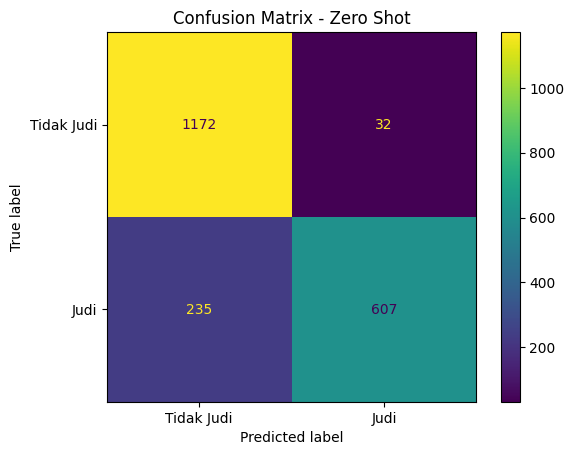

In [15]:
cm_zero = confusion_matrix(
    df_sample.loc[mask_zero, 'label'],
    df_sample.loc[mask_zero, 'Prediksi_ZeroShot']
)

disp_zero = ConfusionMatrixDisplay(confusion_matrix=cm_zero, display_labels=["Tidak Judi", "Judi"])

disp_zero.plot()
plt.title("Confusion Matrix - Zero Shot")
plt.show()


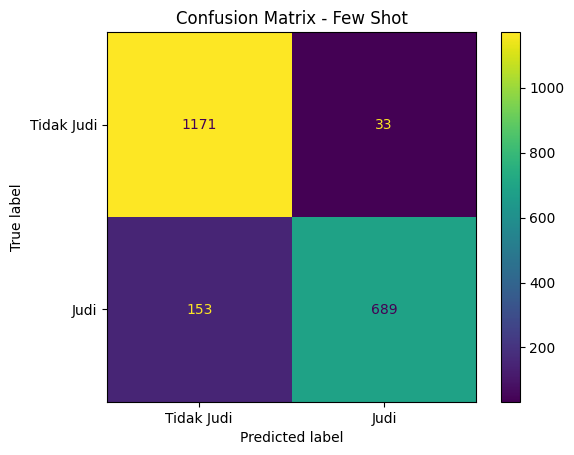

In [16]:
cm_few = confusion_matrix(
    df_sample.loc[mask_few, 'label'],
    df_sample.loc[mask_few, 'Prediksi_FewShot']
)

disp_few = ConfusionMatrixDisplay(confusion_matrix=cm_few, display_labels=["Tidak Judi", "Judi"])

disp_few.plot()
plt.title("Confusion Matrix - Few Shot")
plt.show()